<a href="https://colab.research.google.com/github/PabloDuranLopez/Miprogresionypraticas/blob/main/kernelclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

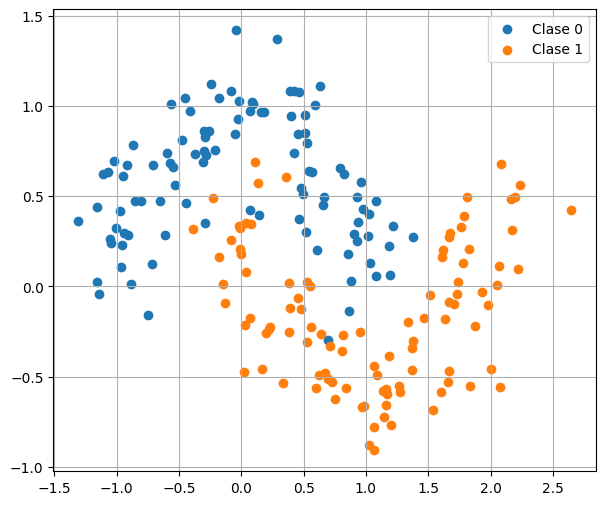

In [575]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
import pandas as pd

X, y = make_moons(
    n_samples=200,
    noise=0.20,
    random_state=15
)

plt.figure(figsize=(7,6))

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    label="Clase 0"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    label="Clase 1"
)

plt.legend()
plt.grid()
plt.show()

In [576]:
class RegresionLogistica:
  def __init__(self, lr=0.01, num_iter=1000, fit_intercept=True, verbose=False):
    self.lr=lr
    self.num_iter=num_iter
    self.fit_intercept=fit_intercept
    self.verbose=verbose

  def intercepto(self, X):
    intercept = np.ones((X.shape[0], 1))
    return np.concatenate((intercept, X), axis=1)

  def sigmoid(self,z):
    return 1 / (1 + np.exp(-z))

  def fit(self,X,y):
    X=self.intercepto(X)
    w=np.zeros(X.shape[1])
    for i in range(self.num_iter):
      p=self.sigmoid(X@w)
      g=X.T@(y-p)
      w+=self.lr*g
    self.w=w
    return self

  def predict_proba(self, X):

    if self.fit_intercept:
        X = self.intercepto(X)

    return self.sigmoid(X @ self.w)


  def predict(self,X):
    X=self.intercepto(X)
    z=X@self.w
    p=self.sigmoid(z)
    pred = (p >= 0.5).astype(int)

    return pred






In [577]:
def sigmoid(z):
  return 1/(1+np.exp(-z))

In [578]:
Phi = np.column_stack((
    np.ones(len(X)),
    X
))

In [579]:
w=np.zeros(Phi.shape[1])
lr=0.023

In [580]:
for i in range(5000):
  p=sigmoid(Phi@w)
  g=Phi.T@(y-p)
  w+=lr*g


In [581]:
w

array([ 0.3945347 ,  1.23087008, -4.56784482])

In [582]:
p = sigmoid(Phi @ w)

In [583]:
pred = (p >= 0.5).astype(int)

In [584]:
accuracy = np.mean(pred == y)

print(accuracy)

0.855


In [585]:
x1 = np.linspace(
    X[:,0].min()-0.5,
    X[:,0].max()+0.5,
    300
)

x2 = np.linspace(
    X[:,1].min()-0.5,
    X[:,1].max()+0.5,
    300
)

xx1, xx2 = np.meshgrid(x1,x2)

In [586]:
Phi_grid = np.column_stack((
    np.ones(xx1.size),
    xx1.ravel(),
    xx2.ravel()
))

In [587]:
P = sigmoid(Phi_grid @ w)

P = P.reshape(xx1.shape)

In [588]:
Phi_grid.shape

(90000, 3)

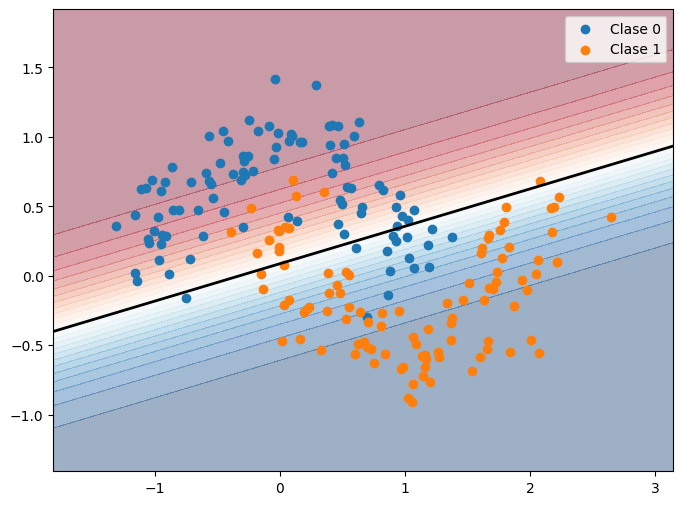

In [589]:
plt.figure(figsize=(8,6))

plt.contourf(
    xx1,
    xx2,
    P,
    levels=30,
    cmap="RdBu",
    alpha=0.4
)

plt.contour(
    xx1,
    xx2,
    P,
    levels=[0.5],
    colors="black",
    linewidths=2
)

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    label="Clase 0"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    label="Clase 1"
)

plt.legend()

plt.show()

In [590]:
M = 30

indices = np.random.choice(
    len(X),
    M,
    replace=False
)

centros = X[indices]

In [591]:
def RBF(X, centros, sigma):

    Phi = np.zeros((len(X), len(centros)))

    for i, c in enumerate(centros):

        dist = np.sum((X-c)**2, axis=1)

        Phi[:, i] = np.exp(
            -dist/(2*sigma**2)
        )

    return Phi

In [592]:
Phi = RBF(
    X,
    centros,
    sigma=0.30
)

In [593]:
Phi.shape

(200, 30)

In [594]:
modelo = RegresionLogistica(
    lr=0.02,
    num_iter=5000
)

modelo.fit(Phi, y)

In [595]:
grid = np.column_stack((
    xx1.ravel(),
    xx2.ravel()
))

Phi_grid = RBF(
    grid,
    centros,
    sigma=0.30
)

pred = modelo.predict(Phi_grid)

In [596]:
P = modelo.predict_proba(Phi_grid)
P = P.reshape(xx1.shape)

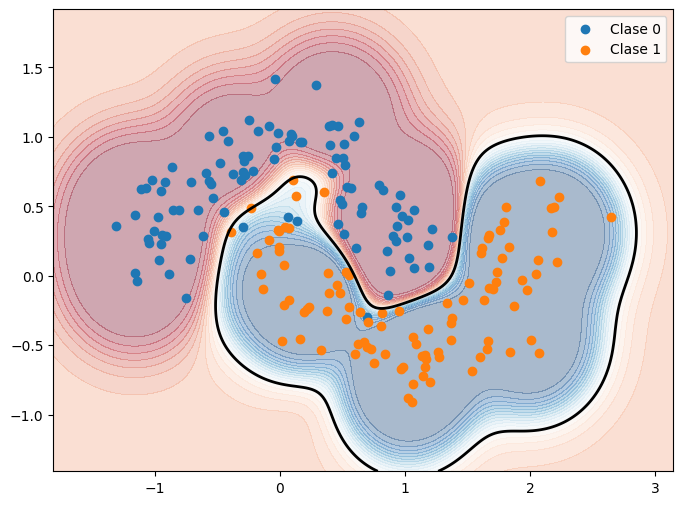

In [597]:
plt.figure(figsize=(8,6))

plt.contourf(
    xx1,
    xx2,
    P,
    levels=30,
    cmap="RdBu",
    alpha=0.35
)

plt.contour(
    xx1,
    xx2,
    P,
    levels=[0.5],
    colors="black",
    linewidths=2
)

plt.scatter(
    X[y==0,0],
    X[y==0,1],
    label="Clase 0"
)

plt.scatter(
    X[y==1,0],
    X[y==1,1],
    label="Clase 1"
)

plt.legend()

plt.show()

In [598]:
y_pred=modelo.predict(Phi)

In [599]:
np.mean(y_pred==y)

np.float64(0.97)

In [600]:
def kernel_matrix(X1, X2, l, theta0):

    X1 = np.atleast_2d(X1)
    X2 = np.atleast_2d(X2)

    dist = np.sum(
        (X1[:,None,:]-X2[None,:,:])**2,
        axis=2
    )

    return theta0*np.exp(
        -dist/(2*l**2)
    )

In [601]:
K = kernel_matrix(
    X,
    X,
    l=0.30,
    theta0=1
)

In [602]:
modelo.fit(K,y)

In [611]:
np.mean(modelo.predict(K)==y)

np.float64(0.98)

In [603]:
K_star = kernel_matrix(
    grid,
    X,
    0.015,
    1
)

In [604]:
alpha = np.linalg.solve(
    K + 1*np.eye(len(K)),
    y
)

In [605]:
y_pred = K_star @ alpha

In [623]:
y_p=K@alpha

In [624]:
y_p=(y_p>=0.5).astype(int)

In [625]:
np.mean(y_p==y)

np.float64(0.96)

In [606]:
y_pred = y_pred.reshape(xx1.shape)

In [607]:
y_pred=(P>=0.5).astype(int)

In [608]:
y_pred.shape

(300, 300)

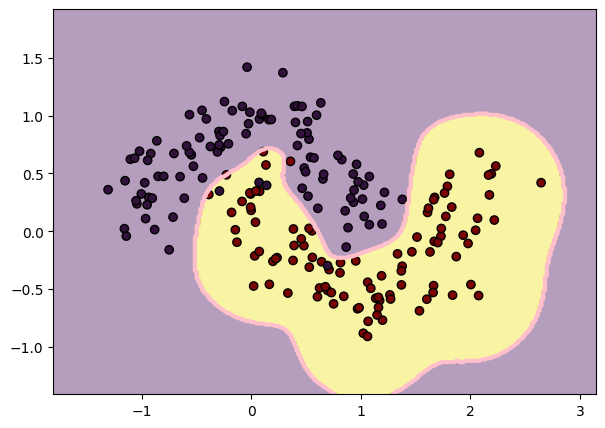

In [616]:
plt.figure(figsize=(7,5))

plt.contourf(xx1, xx2, y_pred, levels=20, alpha=0.4)
plt.contour(
    xx1,
    xx2,
    y_pred,
    levels=[0],
    colors="pink",
    linewidths=3
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="turbo",
    edgecolors="k"
)

plt.show()

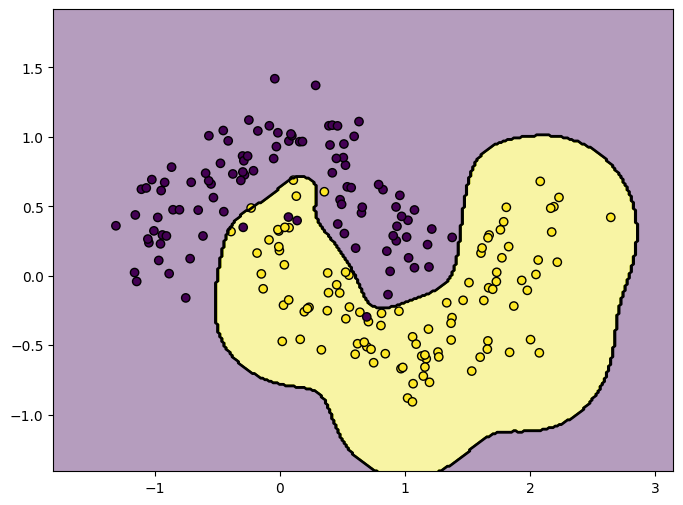

In [614]:
plt.figure(figsize=(8,6))

plt.contourf(xx1, xx2, y_pred, levels=20, alpha=0.4)

plt.contour(
    xx1,
    xx2,
    y_pred,
    levels=[-1,-0.5,0,0.5,1],
    colors="black"
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    edgecolors="k"
)